In [57]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import subprocess
import pandas as pd
import re

In [64]:
def map_cc(pdb_file, map_file):

    cc_per_res_filename = "cc_per_residue.log"

    cmd = [
        "/Users/tjlane/opt/phenix/phenix_bin/phenix.map_correlations",
        "compute.cc_per_residue=True",
        f"{pdb_file}",
        f"{map_file}",
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        check=True,
    )

    df = pd.read_csv(
        cc_per_res_filename,
        sep=r"\s+",
        header=None,
        names=["chain", "resname", "resid", "mapcc", "bfactor", "occ"]
    )

    protein = df[df.chain == "A"]
    p = Path(cc_per_res_filename)
    p.unlink(missing_ok=True)

    return protein


def xtriage_isigi(pdb_file, mtz_file):
    

    cmd = [
        "/Users/tjlane/opt/phenix/phenix_bin/phenix.xtriage",
        f"{pdb_file}",
        f"{mtz_file}",
    ]

    result = subprocess.run(
        cmd,
        capture_output=True,
        text=True,
        check=True,
    )

    with open("logfile.log", "r") as f:
        m = re.search(r"Overall <I/sigma> for this dataset is\s+([-+]?\d*\.?\d+)", f.read())

    if m:
        value = float(m.group(1))

    for file in ["logfile.log", "map_model_fsc.log"]:
        p = Path(file)
        p.unlink(missing_ok=True)

    return value


In [62]:
metadata = pd.read_csv("metadata.csv")

In [75]:
dfs = []
isigis = []

pdb_dir = Path("./pdb")
map_dir = Path("./map")
mtz_dir = Path("./mtz")

for i,pdb_file in enumerate(pdb_dir.glob("*.pdb")):

    map_file = map_dir / Path(pdb_file.stem + "_map.mtz")
    mtz_file = mtz_dir / Path(pdb_file.stem + "_data.mtz")

    if map_file.exists():
        df = map_cc(pdb_file, map_file)
        dfs.append(df)
    
    # if mtz_file.exists():
    #     isigi = xtriage_isigi(pdb_file, mtz_file)
    #     isigis.append(isigi)

In [89]:
joined = pd.concat(
    [df.set_index("resid")["mapcc"] for df in dfs],
    axis=1
)

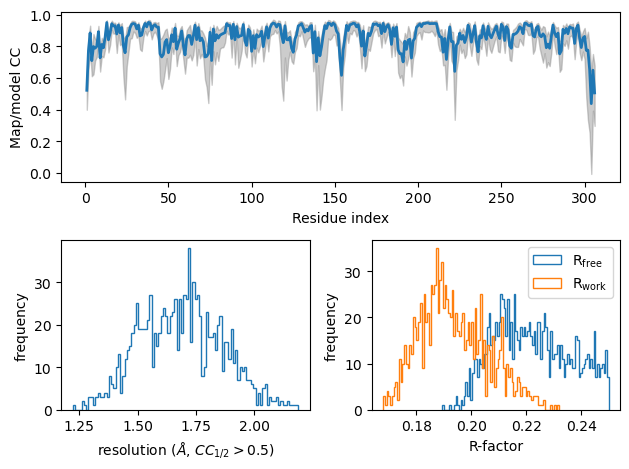

In [95]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2)

ax_main = fig.add_subplot(gs[0, :])


ax_main.fill_between(
    joined.index.values,
    joined.quantile(0.0, axis=1).to_numpy(),
    joined.quantile(1, axis=1).to_numpy(),
    alpha=0.4,
    color='grey'
)
ax_main.plot(joined.index.values, joined.mean(axis=1), linewidth=2)
ax_main.set_xlabel("Residue index")
ax_main.set_ylabel("Map/model CC")


ax_hist1 = fig.add_subplot(gs[1, 0])
ax_hist1.hist(metadata["resolution_cut"], histtype="step", bins=100)
ax_hist1.set_xlabel(r"resolution ($\AA$, $CC_{1/2} > 0.5$)")
ax_hist1.set_ylabel("frequency")


ax_hist2 = fig.add_subplot(gs[1, 1])
ax_hist2.hist(metadata["rfree"], histtype="step", bins=100)
ax_hist2.hist(metadata["rwork"], histtype="step", bins=100)
ax_hist2.legend([r"R$_\mathrm{free}$", r"R$_\mathrm{work}$"])
ax_hist2.set_xlabel(r"R-factor")
ax_hist2.set_ylabel("frequency")

plt.tight_layout()
plt.savefig("dataset_stats_overview.pdf")
plt.savefig("dataset_stats_overview.png")
plt.show()


In [79]:
joined.to_csv("joined.csv")